# MDR-TS v21.3
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Tue Jan 6th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v21.1
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/derived_8.0/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

Adapted for a Macbook M2 Pro environment.

**What's new?**

- Sliding Threshold

## Imports

In [1]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import xgboost as xgb

import torch
import pickle

models_root = os.path.abspath("../../")
if models_root not in sys.path:
    sys.path.insert(0, models_root)

from Temporal.Utils.dashboard import metrics_dashboard

import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

imports loaded
using: cpu


In [2]:
SEED = 42
DEEP_SEARCH = 40

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 3.2.0
  Running in Colab: False
  GPU available: False
environment setup complete


In [3]:
VERSION = "v21"
SUBVERSION = "v21.3"
RUN_NAME = "mdr_ts_v21_3"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR/Models/Temporal/v21/v21.3

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


In [4]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_8.0/train.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_8.0/val.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_8.0/test.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/train.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/val.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/test.csv


In [5]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 499

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'elev', 'slope', 'aspect', 'DOY', 'SMAP_sm_am_interp', 'SMAP_sm_pm_interp', 'soil_moisture_5cm', 'J_aspect_deg', 'J_bio_bio01', 'J_bio_bio02', 'J_bio_bio03', 'J_bio_bio04', 'J_bio_bio05', 'J_bio_bio06', 'J_bio_bio07', 'J_bio_bio08', 'J_bio_bio09', 'J_bio_bio10']


## Features

In [6]:
TARGET_COL = "soil_moisture_5cm"
KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

### Transition

In [7]:
FEATURE_COLS_TRANSITION = [
    "SMAP_sm_pm_interp_ema02",
    "SMAP_sm_interp_grad7",
    "SMAP_ampm_diff_interp",

    "SMAP_sm_interp_lag1",
    "SMAP_sm_interp_diff1",
    "SMAP_sm_interp_rollmean7",

    "G_API",
    "G_rain_sum_3d",
    "G_rain_sum_7d",
    "V_ema_G_API_kobs7",
    "V_ema_G_API_kobs14",
    "V_ema_G_API_kobs30",
    "V_rollmean_G_API_kobs7",
    "V_rollmean_G_API_kobs14",
    "V_rollcv_G_API_kobs7",
    "A_d_G_API_kobs7",

    "A_d_E_SAR_diff_kobs14",
    "V_ema_LST_modis_kobs7",
    "A_d_LST_modis_kobs14",
    "V_rollmin_LST_modis_kobs30",
    "V_rollmean_s2_b11_kobs7",
    "A_d_F_NDMI_kobs7",

    "year_frac", "sin_year", "cos_year",
    "API_x_year", "SMAP_x_year",
    "slope", "elev",
    "K_slope_sin", "K_slope_cos", "K_aspect_cos",
    "J_clay_wfrac_b0", "J_sand_wfrac_b0",
]

### Dry

In [8]:
FEATURE_COLS_DRY = [
    "SMAP_sm_pm_interp_ema02",
    "SMAP_sm_interp_grad7",
    "SMAP_sm_interp_diff1",
    "A_d_SMAP_sm_interp_kobs14",

    "V_ema_LST_modis_kobs7",
    "V_rollmin_LST_modis_kobs30",
    "A_d_LST_modis_kobs14",

    "slope", "elev",
    "K_slope_sin", "K_slope_cos", "K_aspect_cos",
    "J_clay_wfrac_b0", "J_sand_wfrac_b0",

    "G_API",
    "V_ema_G_API_kobs14",
    "C_lag_G_API_kobs1",

    "G_DSLR",

    "V_rollmean_s2_b11_kobs7",
    "year_frac", "sin_year", "cos_year",
]


### Wet

In [9]:
FEATURE_COLS_WET = [
    "SMAP_sm_interp_diff1",
    "SMAP_sm_interp_rollstd7",
    "SMAP_sm_interp_rollrange7",
    "SMAP_sm_interp_pctchg",
    "A_d_SMAP_sm_interp_kobs7",
    "A_grad_SMAP_sm_interp_kobs7",
    "A_pct_SMAP_sm_interp",

    "SMAP_sm_interp_lag7",

    "G_API",
    "G_rain_sum_3d",
    "G_rain_sum_7d",

    "G_rain_sum_30d",

    "V_rollstd_G_API_kobs7",
    "V_rollcv_G_API_kobs7",
    "A_d_G_API_kobs7",

    "A_d_E_SAR_diff_kobs1",
    "A_d_E_SAR_diff_kobs7",
    "A_grad_E_SAR_diff_kobs7",
    "A_grad_E_SAR_ratio_kobs7",
    "V_rollstd_E_SAR_diff_kobs7",
    "V_rollstd_E_SAR_ratio_kobs7",

    "V_rollstd_F_NDMI_kobs7",
    "A_d_F_NDMI_kobs7",

    "year_frac", "sin_year", "cos_year",
    "slope", "elev",
]

### Interaction Features

### New: WET

In [10]:
INTERACTION_SPECS = {
    "wet_rain7_x_LST": ("G_rain_sum_7d", "LST"),
    "wet_api_x_LST": ("G_API", "LST"),
    "wet_rain7_x_NDMI": ("G_rain_sum_7d", "F_NDMI"),
    "wet_rain7_x_slope": ("G_rain_sum_7d", "slope"),
    "wet_smaplag7_x_sin_year": ("SMAP_sm_interp_lag7", "sin_year"),
    "wet_smaplag7_x_cos_year": ("SMAP_sm_interp_lag7", "cos_year"),
}

dfs = {
    "train": train_df,
    "val": val_df,
    "test": test_df,
}

created_features = []
skipped_features = []

for new_col, (col_a, col_b) in INTERACTION_SPECS.items():
    missing = []
    for split_name, df in dfs.items():
        for col in (col_a, col_b):
            if col not in df.columns and col not in missing:
                missing.append(col)

    if missing:
        skipped_features.append((new_col, tuple(missing)))
        continue

    for split_name, df in dfs.items():
        df[new_col] = df[col_a] * df[col_b]

    created_features.append(new_col)

print("Created interaction features:")
for c in created_features:
    print("  ", c)

if skipped_features:
    print("\nSkipped features due to missing source columns:")
    for feat, missing in skipped_features:
        print(f"  {feat}: missing {missing}")

train_df["wet_indicator_proxy"] = (train_df["G_rain_sum_7d"] + train_df["G_API"])
val_df["wet_indicator_proxy"] = (val_df["G_rain_sum_7d"] + val_df["G_API"])
test_df["wet_indicator_proxy"] = (test_df["G_rain_sum_7d"] + test_df["G_API"])

FEATURE_COLS_WET = FEATURE_COLS_WET + [c for c in created_features if c not in FEATURE_COLS_WET]

print("new wet feature count:", len(FEATURE_COLS_WET))
print("added to wet model:", [c for c in created_features if c in FEATURE_COLS_WET])

Created interaction features:
   wet_rain7_x_NDMI
   wet_rain7_x_slope
   wet_smaplag7_x_sin_year
   wet_smaplag7_x_cos_year

Skipped features due to missing source columns:
  wet_rain7_x_LST: missing ('LST',)
  wet_api_x_LST: missing ('LST',)
new wet feature count: 32
added to wet model: ['wet_rain7_x_NDMI', 'wet_rain7_x_slope', 'wet_smaplag7_x_sin_year', 'wet_smaplag7_x_cos_year']


### New: Transition

In [11]:
train_df["tr_api_x_lst"] = train_df["G_API"] * train_df["LST_modis"]
val_df["tr_api_x_lst"]   = val_df["G_API"] * val_df["LST_modis"]
test_df["tr_api_x_lst"]  = test_df["G_API"] * test_df["LST_modis"]

train_df["tr_api_x_slope"] = train_df["G_API"] * train_df["slope"]
val_df["tr_api_x_slope"]   = val_df["G_API"] * val_df["slope"]
test_df["tr_api_x_slope"]  = test_df["G_API"] * test_df["slope"]

train_df["tr_smap_x_season"] = train_df["SMAP_sm_interp"] * train_df["sin_year"]
val_df["tr_smap_x_season"]   = val_df["SMAP_sm_interp"] * val_df["sin_year"]
test_df["tr_smap_x_season"]  = test_df["SMAP_sm_interp"] * test_df["sin_year"]

FEATURE_COLS_TRANSITION += [
    "tr_api_x_lst",
    "tr_api_x_slope",
    "tr_smap_x_season"
]

In [12]:
def _check_cols(df, cols, name):
    missing = sorted(set(cols) - set(df.columns))
    if missing:
        raise ValueError(f"Missing columns in {name}: {missing}")

for _df_name, _df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    _check_cols(_df, KEEP_META_COLS + [TARGET_COL], _df_name)
    _check_cols(_df, FEATURE_COLS_TRANSITION, f"{_df_name} (BASE)")
    _check_cols(_df, FEATURE_COLS_DRY, f"{_df_name} (DRY)")
    _check_cols(_df, FEATURE_COLS_WET, f"{_df_name} (WET)")

print("Columns locked")
print("  BASE features:", len(FEATURE_COLS_TRANSITION))
print("  DRY  features:", len(FEATURE_COLS_DRY))
print("  WET  features:", len(FEATURE_COLS_WET))
print("  Target:", TARGET_COL)

Columns locked
  BASE features: 37
  DRY  features: 22
  WET  features: 32
  Target: soil_moisture_5cm


## Utils

In [13]:
def get_metrics_dict(y_true, y_pred, prefix=""):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    err = y_true - y_pred
    ae = np.abs(err)

    r2 = float(r2_score(y_true, y_pred))
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(root_mean_squared_error(y_true, y_pred))

    bias = float(np.mean(err))
    ubrmse = float(np.std(err))

    q_err = np.quantile(err, [0.05, 0.25, 0.50, 0.75, 0.95])

    return {
        f"{prefix}n": int(len(y_true)),
        f"{prefix}r2": r2,
        f"{prefix}mae": mae,
        f"{prefix}rmse": rmse,
        f"{prefix}ubrmse": ubrmse,
        f"{prefix}bias": bias,
        f"{prefix}med_ae": float(np.median(ae)),
        f"{prefix}p90_ae": float(np.quantile(ae, 0.90)),
        f"{prefix}q05_err": float(q_err[0]),
        f"{prefix}q50_err": float(q_err[2]),
        f"{prefix}q95_err": float(q_err[4]),
    }

def neat_print(metrics, title=None, decimals=5):
    preferred_order = [
        "n", "r2", "mae", "rmse", "ubrmse", "bias",
        "med_ae", "p90_ae",
        "q05_err", "q50_err", "q95_err",
    ]

    keys = list(metrics.keys())
    if "_" in keys[0]:
        prefix = keys[0].split("_")[0] + "_"
    else:
        prefix = ""

    ordered_keys = []
    for k in preferred_order:
        full_key = prefix + k
        if full_key in metrics:
            ordered_keys.append(full_key)

    for k in metrics:
        if k not in ordered_keys:
            ordered_keys.append(k)

    if title:
        print(f"\n{title}")
    print("=" * 42)
    print(f"{'Metric':<18} {'Value':>18}")
    print("-" * 42)

    for k in ordered_keys:
        v = metrics[k]

        if isinstance(v, int):
            val_str = f"{v:,}"
        else:
            val_str = f"{v:.{decimals}f}"

        print(f"{k:<18} {val_str:>18}")

    print("=" * 42)

def get_xgb_importance(model, feature_cols):
    imp = pd.Series(model.feature_importances_, index=feature_cols)
    s = imp.sum()
    if s > 0:
        imp = imp / s
    return imp

TOP_K = 15

def plot_top_features(model, feature_cols, title):
    imp = get_xgb_importance(model, feature_cols)
    imp_top = imp.sort_values(ascending=False).head(TOP_K)

    print(f"\n{title} - Top {TOP_K} Features")
    print("=" * 50)
    print(imp_top.to_string())

    plt.figure(figsize=(6, max(4, 0.4 * TOP_K)))
    y = np.arange(len(imp_top))

    plt.barh(y, imp_top.values)
    plt.yticks(y, imp_top.index)
    plt.gca().invert_yaxis()

    plt.title(title)
    plt.xlabel("Normalized importance")
    plt.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

### Split

In [14]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     6868
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2017-01-01 -- 2020-12-31

VAL
  rows:     2720
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2021-01-01 -- 2022-12-31

TEST
  rows:     4016
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2023-01-01 -- 2025-12-31

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']

-- split locked --


In [15]:
y_train = train_df[TARGET_COL].copy()
y_val = val_df[TARGET_COL].copy()
y_test = test_df[TARGET_COL].copy()

trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)
y_trainval = trainval_df[TARGET_COL].copy()

X_train_dry = train_df[FEATURE_COLS_DRY].copy()
X_val_dry = val_df[FEATURE_COLS_DRY].copy()
X_test_dry = test_df[FEATURE_COLS_DRY].copy()

X_trainval_dry = trainval_df[FEATURE_COLS_DRY].copy()

X_train_transition = train_df[FEATURE_COLS_TRANSITION].copy()
X_val_transition = val_df[FEATURE_COLS_TRANSITION].copy()
X_test_transition = test_df[FEATURE_COLS_TRANSITION].copy()

X_trainval_transition = trainval_df[FEATURE_COLS_TRANSITION].copy()

X_train_wet = train_df[FEATURE_COLS_WET].copy()
X_val_wet = val_df[FEATURE_COLS_WET].copy()
X_test_wet = test_df[FEATURE_COLS_WET].copy()

X_trainval_wet = trainval_df[FEATURE_COLS_WET].copy()

print("\nMatrix shapes:")
print("  DRY        train:", X_train_dry.shape,        "val:", X_val_dry.shape,        "test:", X_test_dry.shape)
print("  TRANSITION train:", X_train_transition.shape, "val:", X_val_transition.shape, "test:", X_test_transition.shape)
print("  WET        train:", X_train_wet.shape,        "val:", X_val_wet.shape,        "test:", X_test_wet.shape)

print("\nTrain+Val shapes:")
print("  y_trainval:", y_trainval.shape)
print("  DRY       trainval:", X_trainval_dry.shape)
print("  TRANSITION trainval:", X_trainval_transition.shape)
print("  WET       trainval:", X_trainval_wet.shape)


Matrix shapes:
  DRY        train: (6868, 22) val: (2720, 22) test: (4016, 22)
  TRANSITION train: (6868, 37) val: (2720, 37) test: (4016, 37)
  WET        train: (6868, 32) val: (2720, 32) test: (4016, 32)

Train+Val shapes:
  y_trainval: (9588,)
  DRY       trainval: (9588, 22)
  TRANSITION trainval: (9588, 37)
  WET       trainval: (9588, 32)


### Inner Split

In [16]:
# SUPER IMPORTANT
# 0: dry
# 1: transition
# 2: wet

t1 = 0.20   # 33rd percentile / dry threshold
t2 = 0.313  # 66th percentile / wet threshold

def assign_regime(y, t1=0.20, t2=0.313):
    y_arr = np.asarray(y).ravel()
    reg = np.zeros_like(y_arr, dtype=int)
    reg[(y_arr > t1) & (y_arr <= t2)] = 1
    reg[y_arr > t2] = 2
    return reg

reg_train = assign_regime(y_train, t1, t2)
reg_val   = assign_regime(y_val, t1, t2)
reg_test  = assign_regime(y_test, t1, t2)

mask_train_dry = (reg_train == 0)
mask_train_transition = (reg_train == 1)
mask_train_wet = (reg_train == 2)

mask_val_dry = (reg_val == 0)
mask_val_transition = (reg_val == 1)
mask_val_wet = (reg_val == 2)

mask_test_dry = (reg_test == 0)
mask_test_transition = (reg_test == 1)
mask_test_wet = (reg_test == 2)

y_train_dry = np.asarray(y_train)[mask_train_dry]
y_train_transition = np.asarray(y_train)[mask_train_transition]
y_train_wet = np.asarray(y_train)[mask_train_wet]

y_val_dry = np.asarray(y_val)[mask_val_dry]
y_val_transition = np.asarray(y_val)[mask_val_transition]
y_val_wet = np.asarray(y_val)[mask_val_wet]

y_test_dry = np.asarray(y_test)[mask_test_dry]
y_test_transition = np.asarray(y_test)[mask_test_transition]
y_test_wet = np.asarray(y_test)[mask_test_wet]

print("Train regime counts:", {
    "dry": int(mask_train_dry.sum()),
    "transition": int(mask_train_transition.sum()),
    "wet": int(mask_train_wet.sum())
})
print("Val regime counts:", {
    "dry": int(mask_val_dry.sum()),
    "transition": int(mask_val_transition.sum()),
    "wet": int(mask_val_wet.sum())
})
print("Test regime counts:", {
    "dry": int(mask_test_dry.sum()),
    "transition": int(mask_test_transition.sum()),
    "wet": int(mask_test_wet.sum())
})

Train regime counts: {'dry': 3292, 'transition': 2729, 'wet': 847}
Val regime counts: {'dry': 988, 'transition': 1156, 'wet': 576}
Test regime counts: {'dry': 1509, 'transition': 2015, 'wet': 492}


### Dry Model

In [17]:
XGB_PARAMS_DRY = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    subsample=0.9,
    colsample_bytree=0.8,
    max_depth=8,
    min_child_weight=2,
    n_estimators=5500,
    learning_rate=0.04,
    reg_lambda=1.5,
    reg_alpha=0.03,
    gamma=0.0,
)

X_train_dry_regime = X_train_dry.loc[reg_train == 0].copy()
X_val_dry_regime   = X_val_dry.loc[reg_val == 0].copy()
X_test_dry_regime  = X_test_dry.loc[reg_test == 0].copy()

y_train_dry = y_train.loc[reg_train == 0].copy()
y_val_dry   = y_val.loc[reg_val == 0].copy()
y_test_dry  = y_test.loc[reg_test == 0].copy()

dry_model = xgb.XGBRegressor(**XGB_PARAMS_DRY)

dry_model.fit(
    X_train_dry_regime,
    y_train_dry,
    eval_set=[(X_val_dry_regime, y_val_dry)],
    verbose=False
)

pred_dry_train = dry_model.predict(X_train_dry_regime)
pred_dry_val   = dry_model.predict(X_val_dry_regime)
pred_dry_test  = dry_model.predict(X_test_dry_regime)


Dry Model - Top 15 Features
J_sand_wfrac_b0               0.119004
K_aspect_cos                  0.075873
K_slope_sin                   0.075119
J_clay_wfrac_b0               0.071434
K_slope_cos                   0.064977
year_frac                     0.045116
slope                         0.042929
V_rollmin_LST_modis_kobs30    0.042810
sin_year                      0.040940
cos_year                      0.039811
SMAP_sm_interp_diff1          0.038442
V_ema_G_API_kobs14            0.038214
elev                          0.035516
C_lag_G_API_kobs1             0.035270
A_d_LST_modis_kobs14          0.033618


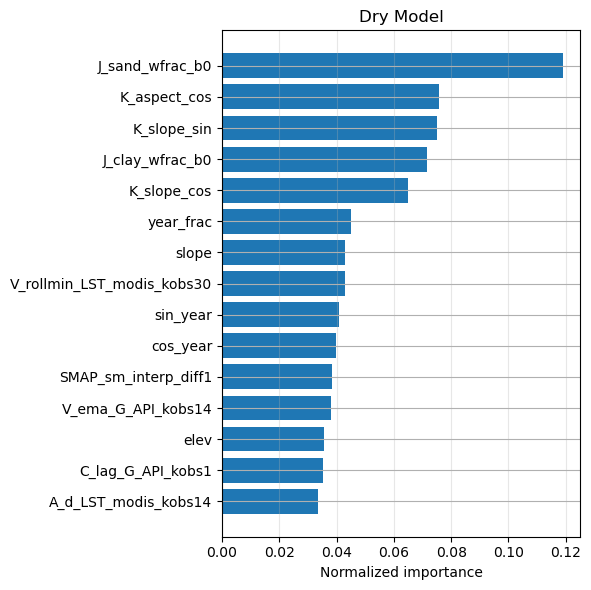

In [18]:
plot_top_features(dry_model, FEATURE_COLS_DRY, "Dry Model")

### Wet Model

In [19]:
XGB_PARAMS_WET = dict(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
    max_depth=4,
    min_child_weight=8,
    subsample=0.9,
    colsample_bytree=0.8,
    n_estimators=2500,
    learning_rate=0.03,
    reg_lambda=1.5,
    reg_alpha=0.0,
)

X_train_wet_regime = X_train_wet.loc[reg_train == 2].copy()
X_val_wet_regime   = X_val_wet.loc[reg_val == 2].copy()
X_test_wet_regime  = X_test_wet.loc[reg_test == 2].copy()

y_train_wet = y_train.loc[reg_train == 2].copy()
y_val_wet   = y_val.loc[reg_val == 2].copy()
y_test_wet  = y_test.loc[reg_test == 2].copy()

wet_baseline = np.median(y_train_wet)

y_train_wet_res = y_train_wet - wet_baseline
y_val_wet_res   = y_val_wet - wet_baseline
y_test_wet_res  = y_test_wet - wet_baseline

wet_model = xgb.XGBRegressor(**XGB_PARAMS_WET)

wet_model.fit(
    X_train_wet_regime,
    y_train_wet_res,
    eval_set=[(X_val_wet_regime, y_val_wet_res)],
    verbose=False
)

pred_res_train = wet_model.predict(X_train_wet_regime)
pred_res_val   = wet_model.predict(X_val_wet_regime)
pred_res_test  = wet_model.predict(X_test_wet_regime)

pred_wet_train = pred_res_train + wet_baseline
pred_wet_val   = pred_res_val + wet_baseline
pred_wet_test  = pred_res_test + wet_baseline


Wet Model - Top 15 Features
elev                          0.334875
slope                         0.136384
cos_year                      0.104394
wet_smaplag7_x_cos_year       0.073265
SMAP_sm_interp_rollrange7     0.030328
A_grad_E_SAR_diff_kobs7       0.028247
G_rain_sum_7d                 0.026190
V_rollstd_E_SAR_diff_kobs7    0.025779
wet_smaplag7_x_sin_year       0.024376
SMAP_sm_interp_lag7           0.020709
A_d_E_SAR_diff_kobs7          0.018496
A_d_SMAP_sm_interp_kobs7      0.017159
wet_rain7_x_slope             0.015712
wet_rain7_x_NDMI              0.014230
A_d_F_NDMI_kobs7              0.012578


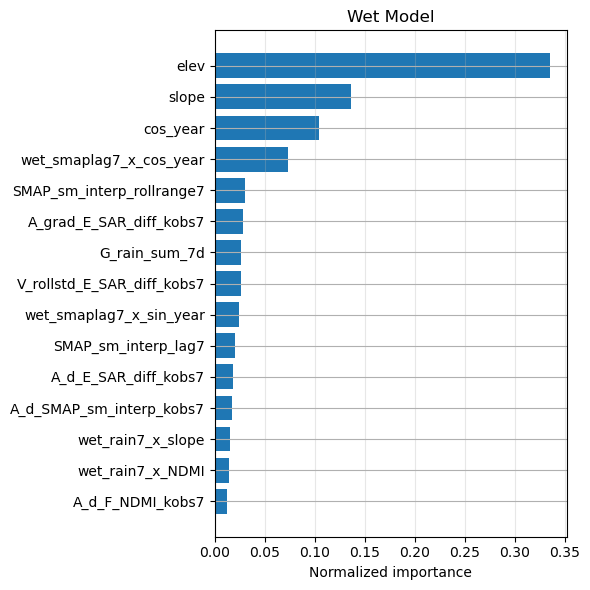

In [20]:
plot_top_features(wet_model, FEATURE_COLS_WET, "Wet Model")

### Transition Model

In [21]:
XGB_PARAMS_TRANSITION = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    max_depth=5,
    min_child_weight=8,
    subsample=0.9,
    colsample_bytree=0.85,
    n_estimators=4000,
    learning_rate=0.03,
    reg_lambda=3.0,
    reg_alpha=0.05,
)

X_train_transition_regime = X_train_transition.loc[reg_train == 1].copy()
X_val_transition_regime   = X_val_transition.loc[reg_val == 1].copy()
X_test_transition_regime  = X_test_transition.loc[reg_test == 1].copy()

y_train_transition = y_train.loc[reg_train == 1].copy()
y_val_transition   = y_val.loc[reg_val == 1].copy()
y_test_transition  = y_test.loc[reg_test == 1].copy()

baseline_train_transition = train_df.loc[reg_train == 1, "SMAP_sm_interp_lag1"].copy()
baseline_val_transition   = val_df.loc[reg_val == 1, "SMAP_sm_interp_lag1"].copy()
baseline_test_transition  = test_df.loc[reg_test == 1, "SMAP_sm_interp_lag1"].copy()

# clean the NaNs so XGB stops complaining - TODO: clean earlier than here
train_valid = (
    np.isfinite(y_train_transition.to_numpy()) &
    np.isfinite(baseline_train_transition.to_numpy()) &
    np.isfinite(X_train_transition_regime.to_numpy()).all(axis=1)
)

val_valid = (
    np.isfinite(y_val_transition.to_numpy()) &
    np.isfinite(baseline_val_transition.to_numpy()) &
    np.isfinite(X_val_transition_regime.to_numpy()).all(axis=1)
)

test_valid = (
    np.isfinite(y_test_transition.to_numpy()) &
    np.isfinite(baseline_test_transition.to_numpy()) &
    np.isfinite(X_test_transition_regime.to_numpy()).all(axis=1)
)

X_train_transition_regime = X_train_transition_regime.loc[train_valid].copy()
X_val_transition_regime   = X_val_transition_regime.loc[val_valid].copy()
X_test_transition_regime  = X_test_transition_regime.loc[test_valid].copy()

y_train_transition = y_train_transition.loc[train_valid].copy()
y_val_transition   = y_val_transition.loc[val_valid].copy()
y_test_transition  = y_test_transition.loc[test_valid].copy()

baseline_train_transition = baseline_train_transition.loc[train_valid].copy()
baseline_val_transition   = baseline_val_transition.loc[val_valid].copy()
baseline_test_transition  = baseline_test_transition.loc[test_valid].copy()

delta_shift = np.median(y_train_transition.to_numpy() - baseline_train_transition.to_numpy())

baseline_train_transition_adj = baseline_train_transition.to_numpy() + delta_shift
baseline_val_transition_adj   = baseline_val_transition.to_numpy() + delta_shift
baseline_test_transition_adj  = baseline_test_transition.to_numpy() + delta_shift

y_train_transition_delta = y_train_transition.to_numpy() - baseline_train_transition_adj
y_val_transition_delta   = y_val_transition.to_numpy() - baseline_val_transition_adj
y_test_transition_delta  = y_test_transition.to_numpy() - baseline_test_transition_adj

print("transition rows kept:")
print(" train:", len(y_train_transition), "| dropped:", (~train_valid).sum())
print(" val  :", len(y_val_transition), "| dropped:", (~val_valid).sum())
print(" test :", len(y_test_transition), "| dropped:", (~test_valid).sum())

print("\nNaNs in delta targets?")
print(" train:", np.isnan(y_train_transition_delta).any())
print(" val  :", np.isnan(y_val_transition_delta).any())
print(" test :", np.isnan(y_test_transition_delta).any())

transition_model = xgb.XGBRegressor(**XGB_PARAMS_TRANSITION)

transition_model.fit(
    X_train_transition_regime,
    y_train_transition_delta,
    eval_set=[(X_val_transition_regime, y_val_transition_delta)],
    verbose=False
)

pred_transition_delta_train = transition_model.predict(X_train_transition_regime)
pred_transition_delta_val   = transition_model.predict(X_val_transition_regime)
pred_transition_delta_test  = transition_model.predict(X_test_transition_regime)

pred_transition_train = pred_transition_delta_train + baseline_train_transition_adj
pred_transition_val   = pred_transition_delta_val + baseline_val_transition_adj
pred_transition_test  = pred_transition_delta_test + baseline_test_transition_adj

bias_correction = np.mean(pred_transition_val - y_val_transition.to_numpy())

pred_transition_train = pred_transition_train - bias_correction
pred_transition_val   = pred_transition_val - bias_correction
pred_transition_test  = pred_transition_test - bias_correction

transition rows kept:
 train: 2334 | dropped: 395
 val  : 1156 | dropped: 0
 test : 1890 | dropped: 125

NaNs in delta targets?
 train: False
 val  : False
 test : False



Transition Model - Top 15 Features
SMAP_sm_interp_lag1           0.172489
slope                         0.051620
elev                          0.049211
SMAP_sm_interp_rollmean7      0.037193
K_slope_cos                   0.031315
SMAP_sm_pm_interp_ema02       0.029867
K_aspect_cos                  0.024634
cos_year                      0.024600
tr_smap_x_season              0.023649
V_rollmin_LST_modis_kobs30    0.022636
K_slope_sin                   0.021745
tr_api_x_slope                0.021457
tr_api_x_lst                  0.020990
SMAP_sm_interp_diff1          0.020984
API_x_year                    0.020956


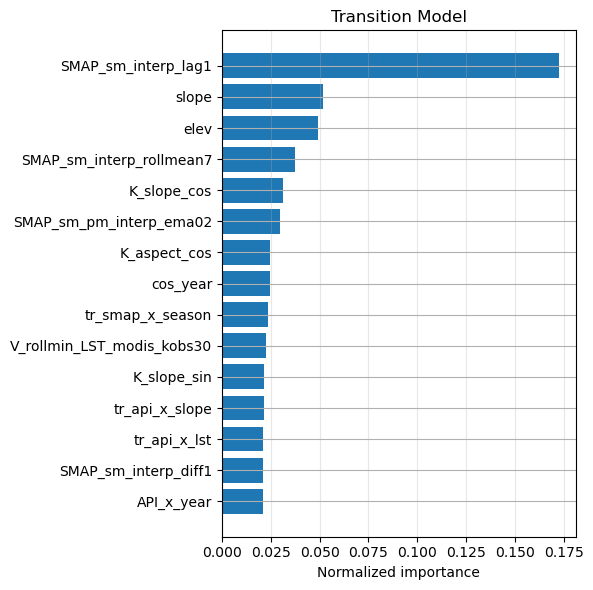

In [22]:
plot_top_features(transition_model, FEATURE_COLS_TRANSITION, "Transition Model")

In [23]:
metrics_dashboard(
    y_val_dry,
    pred_dry_val,
    name="DRY EXPERT ON DRY VAL ROWS",
    return_dict=False
)

metrics_dashboard(
    y_val_transition,
    pred_transition_val,
    name="TRANSITION EXPERT ON TRANSITION VAL ROWS",
    return_dict=False
)

metrics_dashboard(
    y_val_wet,
    pred_wet_val,
    name="WET EXPERT ON WET VAL ROWS",
    return_dict=False
)

In [24]:
neat_print(
    get_metrics_dict(y_val_dry, pred_dry_val, prefix=""),
    "DRY REGIME"
)

neat_print(
    get_metrics_dict(y_val_wet, pred_wet_val, prefix=""),
    "WET REGIME"
)

neat_print(
    get_metrics_dict(y_val_transition, pred_transition_val, prefix=""),
    "TRANSITION REGIME"
)


DRY REGIME
Metric                          Value
------------------------------------------
n                                 988
r2                            0.55101
mae                           0.02292
rmse                          0.03079
ubrmse                        0.03064
bias                          0.00298
med_ae                        0.01662
p90_ae                        0.04802
q05_err                      -0.04395
q50_err                       0.00240
q95_err                       0.05564

WET REGIME
Metric                          Value
------------------------------------------
n                                 576
r2                            0.03213
mae                           0.01514
rmse                          0.02033
ubrmse                        0.01990
bias                          0.00417
med_ae                        0.01204
p90_ae                        0.03153
q05_err                      -0.02474
q50_err                       0.00332
q95_err         

### Residuals

In [25]:
# TODO for all

## Diagnostics

In [30]:
# lock
dry_model_final = dry_model
transition_model_final = transition_model
wet_model_final = wet_model

transition_delta_shift_final = delta_shift
transition_bias_correction_final = bias_correction

wet_baseline_final = wet_baseline

## Replacing Hard-Gating with Regression Gating

In [31]:
best_model_path = "/Users/jbalkovec/Desktop/MDR/Models/Temporal/BEST_MODEL/best_model.pkl"

with open(best_model_path, "rb") as f:
    base_model = pickle.load(f)

if hasattr(base_model, "feature_names_in_") and base_model.feature_names_in_ is not None:
    gate_feature_cols = list(base_model.feature_names_in_)
elif hasattr(base_model, "get_booster") and base_model.get_booster().feature_names is not None:
    gate_feature_cols = list(base_model.get_booster().feature_names)
else:
    raise ValueError("could not recover feature names from best_model.pkl")

missing_val = [c for c in gate_feature_cols if c not in val_df.columns]
missing_test = [c for c in gate_feature_cols if c not in test_df.columns]

if missing_val or missing_test:
    raise ValueError("some gating features are missing from val_df/test_df")

X_val_gate = val_df[gate_feature_cols].copy()
X_test_gate = test_df[gate_feature_cols].copy()

pred_val_base = base_model.predict(X_val_gate)
pred_test_base = base_model.predict(X_test_gate)

In [32]:
reg_val_pred = assign_regime(pred_val_base, t1, t2)
reg_test_pred = assign_regime(pred_test_base, t1, t2)

print("Predicted regime counts (VAL): ", {r: int((reg_val_pred == r).sum()) for r in [0, 1, 2]})
print("Predicted regime counts (TEST):", {r: int((reg_test_pred == r).sum()) for r in [0, 1, 2]})

print("\nVAL percentiles:  ", np.percentile(pred_val_base, [5, 25, 50, 75, 95]))
print("TEST percentiles: ", np.percentile(pred_test_base, [5, 25, 50, 75, 95]))

Predicted regime counts (VAL):  {0: 987, 1: 1148, 2: 585}
Predicted regime counts (TEST): {0: 1477, 1: 2301, 2: 238}

VAL percentiles:   [0.04283174 0.11412831 0.2573294  0.3065871  0.35335422]
TEST percentiles:  [0.04897431 0.1414355  0.24636772 0.28658335 0.31557254]


In [33]:
pred_val_deploy_soft = np.full(len(y_val), np.nan, dtype=float)
pred_test_deploy_soft = np.full(len(y_test), np.nan, dtype=float)

In [34]:
# dry
X_val_dry_full = val_df[FEATURE_COLS_DRY].copy()
valid_dry_val = np.isfinite(X_val_dry_full.to_numpy()).all(axis=1)

pred_val_dry_full = np.full(len(y_val), np.nan, dtype=float)
pred_val_dry_full[valid_dry_val] = dry_model_final.predict(X_val_dry_full.loc[valid_dry_val])

# transition
X_val_transition_full = val_df[FEATURE_COLS_TRANSITION].copy()
baseline_val_transition_full = val_df["SMAP_sm_interp_lag1"].copy()

valid_transition_val = (
    np.isfinite(X_val_transition_full.to_numpy()).all(axis=1) &
    np.isfinite(baseline_val_transition_full.to_numpy())
)

pred_val_transition_full = np.full(len(y_val), np.nan, dtype=float)
pred_delta = transition_model_final.predict(X_val_transition_full.loc[valid_transition_val])
pred_abs = pred_delta + (
    baseline_val_transition_full.loc[valid_transition_val].to_numpy() + transition_delta_shift_final
)
pred_abs = pred_abs - transition_bias_correction_final
pred_val_transition_full[valid_transition_val] = pred_abs

# wet
X_val_wet_full = val_df[FEATURE_COLS_WET].copy()
valid_wet_val = np.isfinite(X_val_wet_full.to_numpy()).all(axis=1)

pred_val_wet_full = np.full(len(y_val), np.nan, dtype=float)
pred_res = wet_model_final.predict(X_val_wet_full.loc[valid_wet_val])
pred_val_wet_full[valid_wet_val] = pred_res + wet_baseline_final

### TEST

In [ ]:
# dry
X_test_dry_full = test_df[FEATURE_COLS_DRY].copy()
valid_dry_test = np.isfinite(X_test_dry_full.to_numpy()).all(axis=1)

pred_test_dry_full = np.full(len(y_test), np.nan, dtype=float)
pred_test_dry_full[valid_dry_test] = dry_model_final.predict(X_test_dry_full.loc[valid_dry_test])

# transition
X_test_transition_full = test_df[FEATURE_COLS_TRANSITION].copy()
baseline_test_transition_full = test_df["SMAP_sm_interp_lag1"].copy()

valid_transition_test = (
    np.isfinite(X_test_transition_full.to_numpy()).all(axis=1) &
    np.isfinite(baseline_test_transition_full.to_numpy())
)

pred_test_transition_full = np.full(len(y_test), np.nan, dtype=float)
pred_delta = transition_model_final.predict(X_test_transition_full.loc[valid_transition_test])
pred_abs = pred_delta + (
    baseline_test_transition_full.loc[valid_transition_test].to_numpy() + transition_delta_shift_final
)
pred_abs = pred_abs - transition_bias_correction_final
pred_test_transition_full[valid_transition_test] = pred_abs

# wet
X_test_wet_full = test_df[FEATURE_COLS_WET].copy()
valid_wet_test = np.isfinite(X_test_wet_full.to_numpy()).all(axis=1)

pred_test_wet_full = np.full(len(y_test), np.nan, dtype=float)
pred_res = wet_model_final.predict(X_test_wet_full.loc[valid_wet_test])
pred_test_wet_full[valid_wet_test] = pred_res + wet_baseline_final

In [36]:
# see analysis.ipynb in BEST_MODELS/
# t1 = 0.19090909090909092
# t2 = 0.2909090909090909

# manual, see analysis.ipynb in BEST_MODELS/
t1 = 0.191
t2 = 0.291

# best of both worlds, see analysis.ipynb in BEST_MODELS/
# t1 = 0.5 * 0.179 + 0.5 * 0.191
# t2 = 0.5 * 0.271 + 0.5 * 0.291

In [37]:
w1 = 0.05   # dry boundary is stable -> smaller blend
w2 = 0.12   # wet boundary is unstable -> wider blend

def soft_weights_asym(signal, t1, t2, w1, w2):
    signal = np.asarray(signal)

    w_dry = np.zeros_like(signal, dtype=float)
    w_transition = np.zeros_like(signal, dtype=float)
    w_wet = np.zeros_like(signal, dtype=float)

    for i, s in enumerate(signal):

        if s <= t1 - w1:
            w_dry[i] = 1.0

        elif s < t1 + w1:
            alpha = (s - (t1 - w1)) / (2 * w1)
            w_dry[i] = 1.0 - alpha
            w_transition[i] = alpha

        elif s <= t2 - w2:
            w_transition[i] = 1.0

        elif s < t2 + w2:
            alpha = (s - (t2 - w2)) / (2 * w2)
            w_transition[i] = 1.0 - alpha
            w_wet[i] = alpha

        else:
            w_wet[i] = 1.0

    return w_dry, w_transition, w_wet

In [43]:
blend_width = 0.08 # from oracle gating...see above

w_dry_val, w_transition_val, w_wet_val = soft_weights_asym(
    pred_val_base, t1, t2, w1, w2
)

w_dry_test, w_transition_test, w_wet_test = soft_weights_asym(
    pred_test_base, t1, t2, w1, w2
)

pred_val_deploy_soft = (
    w_dry_val * pred_val_dry_full +
    w_transition_val * pred_val_transition_full +
    w_wet_val * pred_val_wet_full
)

pred_test_deploy_soft = (
    w_dry_test * pred_test_dry_full +
    w_transition_test * pred_test_transition_full +
    w_wet_test * pred_test_wet_full
)

val_keep = np.isfinite(pred_val_deploy_soft)
test_keep = np.isfinite(pred_test_deploy_soft)

print("Rows evaluated:")
print("  VAL :", int(val_keep.sum()), "/", len(val_keep))
print("  TEST:", int(test_keep.sum()), "/", len(test_keep))
print("  VAL dropped :", int((~val_keep).sum()))
print("  TEST dropped:", int((~test_keep).sum()))


Rows evaluated:
  VAL : 2720 / 2720
  TEST: 3846 / 4016
  VAL dropped : 0
  TEST dropped: 170


In [ ]:
b1 = 0.03   # around t1, needs tunning...this is a good estimate
b2 = 0.05   # around t2, needs tunning...this is a good estimate

In [46]:
signal_val = pred_val_base
signal_test = pred_test_base

mask_val = (
    (np.abs(signal_val - t1) < b1) |
    (np.abs(signal_val - t2) < b2)
)

mask_test = (
    (np.abs(signal_test - t1) < b1) |
    (np.abs(signal_test - t2) < b2)
)

In [57]:
d0_1 = 0.03   # confidence decay around t1
d0_2 = 0.08   # confidence decay around t2

pred_val_soft = pred_val_deploy_soft.copy()
pred_val_final = np.full(len(y_val), np.nan, dtype=float)

dist_val_t1 = np.abs(pred_val_base - t1)
dist_val_t2 = np.abs(pred_val_base - t2)

alpha_val_t1 = np.clip(1.0 - (dist_val_t1 / d0_1), 0.0, 1.0)
alpha_val_t2 = np.clip(1.0 - (dist_val_t2 / d0_2), 0.0, 1.0)

alpha_val = np.maximum(alpha_val_t1, alpha_val_t2)

valid_val = np.isfinite(pred_val_soft) & np.isfinite(pred_val_base)
pred_val_final[valid_val] = (
    alpha_val[valid_val] * pred_val_base[valid_val] +
    (1.0 - alpha_val[valid_val]) * pred_val_soft[valid_val]
)

# TEST
pred_test_soft = pred_test_deploy_soft.copy()
pred_test_final = np.full(len(y_test), np.nan, dtype=float)

dist_test_t1 = np.abs(pred_test_base - t1)
dist_test_t2 = np.abs(pred_test_base - t2)

alpha_test_t1 = np.clip(1.0 - (dist_test_t1 / d0_1), 0.0, 1.0)
alpha_test_t2 = np.clip(1.0 - (dist_test_t2 / d0_2), 0.0, 1.0)

alpha_test = np.maximum(alpha_test_t1, alpha_test_t2)

valid_test = np.isfinite(pred_test_soft) & np.isfinite(pred_test_base)
pred_test_final[valid_test] = (
    alpha_test[valid_test] * pred_test_base[valid_test] +
    (1.0 - alpha_test[valid_test]) * pred_test_soft[valid_test]
)

val_keep = np.isfinite(pred_val_final)
test_keep = np.isfinite(pred_test_final)

print("Rows evaluated:")
print("  VAL :", int(val_keep.sum()), "/", len(val_keep))
print("  TEST:", int(test_keep.sum()), "/", len(test_keep))
print("  VAL dropped :", int((~val_keep).sum()))
print("  TEST dropped:", int((~test_keep).sum()))

print("\nAlpha summary (VAL):")
print(np.percentile(alpha_val[valid_val], [0, 25, 50, 75, 90, 95, 100]))

print("\nAlpha summary (TEST):")
print(np.percentile(alpha_test[valid_test], [0, 25, 50, 75, 90, 95, 100]))

Rows evaluated:
  VAL : 2720 / 2720
  TEST: 3846 / 4016
  VAL dropped : 0
  TEST dropped: 170

Alpha summary (VAL):
[0.         0.         0.39057165 0.73331371 0.89115139 0.94761845
 0.99969786]

Alpha summary (TEST):
[0.         0.         0.58800152 0.82951255 0.93520379 0.96649726
 0.99973845]


In [58]:
# override
pred_val_final = pred_val_soft.copy()
pred_test_final = pred_test_soft.copy()

pred_val_final[mask_val] = pred_val_base[mask_val]
pred_test_final[mask_test] = pred_test_base[mask_test]

In [59]:
neat_print(
    get_metrics_dict(y_val.iloc[val_keep], pred_val_final[val_keep], prefix=""),
    f"COMBINED MODEL - VAL (PREDICTED SOFT GATING + BASE FALLBACK, b1={b1}, b2={b2})"
)


COMBINED MODEL - VAL (PREDICTED SOFT GATING + BASE FALLBACK, b1=0.05, b2=0.12)
Metric                          Value
------------------------------------------
n                               2,720
r2                            0.98030
mae                           0.00683
rmse                          0.01475
ubrmse                        0.01472
bias                         -0.00084
med_ae                        0.00096
p90_ae                        0.02659
q05_err                      -0.03009
q50_err                      -0.00006
q95_err                       0.01915


In [60]:
neat_print(
    get_metrics_dict(y_test.iloc[test_keep], pred_test_final[test_keep], prefix=""),
    f"COMBINED MODEL - TEST (PREDICTED SOFT GATING + BASE FALLBACK, b1={b1}, b2={b2})"
)


COMBINED MODEL - TEST (PREDICTED SOFT GATING + BASE FALLBACK, b1=0.05, b2=0.12)
Metric                          Value
------------------------------------------
n                               3,846
r2                            0.82151
mae                           0.02918
rmse                          0.04055
ubrmse                        0.04054
bias                         -0.00106
med_ae                        0.02159
p90_ae                        0.06107
q05_err                      -0.06762
q50_err                      -0.00071
q95_err                       0.05635


In [61]:
metrics_dashboard(
    y_val.iloc[val_keep],
    pred_val_final[val_keep],
    name=f"COMBINED MODEL - VAL (PREDICTED SOFT GATING + BASE FALLBACK, b1={b1}, b2={b2})"
)

metrics_dashboard(
    y_test.iloc[test_keep],
    pred_test_final[test_keep],
    name=f"COMBINED MODEL - TEST (PREDICTED SOFT GATING + BASE FALLBACK, b1={b1}, b2={b2})"
)

In [64]:
abs_err_base = np.abs(pred_test_base - y_test)
abs_err_soft = np.abs(pred_test_deploy_soft - y_test)

print("expert better rate:", np.mean(abs_err_soft < abs_err_base))

expert better rate: 0.4531872509960159


## Diagrams & Plots

In [65]:
y_test_np = y_test.to_numpy()

pred_base = pred_test_base
pred_soft = pred_test_deploy_soft
pred_dry = pred_test_dry_full
pred_trans = pred_test_transition_full
pred_wet = pred_test_wet_full

w_dry = w_dry_test
w_trans = w_transition_test
w_wet = w_wet_test

plot_keep = (
    np.isfinite(y_test_np) &
    np.isfinite(pred_base) &
    np.isfinite(pred_soft) &
    np.isfinite(pred_dry) &
    np.isfinite(pred_trans) &
    np.isfinite(pred_wet) &
    np.isfinite(w_dry) &
    np.isfinite(w_trans) &
    np.isfinite(w_wet)
)

print("Rows kept for plotting:", int(plot_keep.sum()), "/", len(plot_keep))

y_plot = y_test_np[plot_keep]
base_plot = pred_base[plot_keep]
soft_plot = pred_soft[plot_keep]
dry_plot = pred_dry[plot_keep]
trans_plot = pred_trans[plot_keep]
wet_plot = pred_wet[plot_keep]

w_dry_plot = w_dry[plot_keep]
w_trans_plot = w_trans[plot_keep]
w_wet_plot = w_wet[plot_keep]

dominant_expert = np.argmax(
    np.column_stack([w_dry_plot, w_trans_plot, w_wet_plot]),
    axis=1
)

expert_name = np.array(["DRY", "TRANS", "WET"])[dominant_expert]

expert_conf = np.max(
    np.column_stack([w_dry_plot, w_trans_plot, w_wet_plot]),
    axis=1
)

abs_err_base = np.abs(base_plot - y_plot)
abs_err_soft = np.abs(soft_plot - y_plot)

expert_better = abs_err_soft < abs_err_base
base_better = ~expert_better

dist_t1 = np.abs(base_plot - t1)
dist_t2 = np.abs(base_plot - t2)
dist_nearest = np.minimum(dist_t1, dist_t2)

ambiguous_band = 0.03
near_boundary = dist_nearest < ambiguous_band

print("Expert better rate (plot subset):", expert_better.mean())
print("Near-boundary rate:", near_boundary.mean())

Rows kept for plotting: 3846 / 4016
Expert better rate (plot subset): 0.47321892875715027
Near-boundary rate: 0.531461258450338


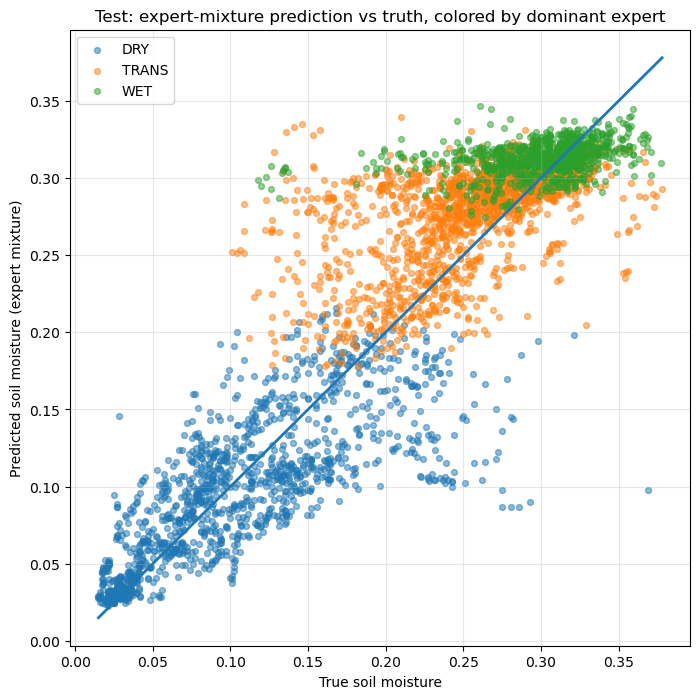

In [66]:
plt.figure(figsize=(8, 8))

for label in ["DRY", "TRANS", "WET"]:
    m = expert_name == label
    plt.scatter(
        y_plot[m],
        soft_plot[m],
        s=18,
        alpha=0.5,
        label=label
    )

mn = min(y_plot.min(), soft_plot.min())
mx = max(y_plot.max(), soft_plot.max())
plt.plot([mn, mx], [mn, mx], linewidth=2)

plt.xlabel("True soil moisture")
plt.ylabel("Predicted soil moisture (expert mixture)")
plt.title("Test: expert-mixture prediction vs truth, colored by dominant expert")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

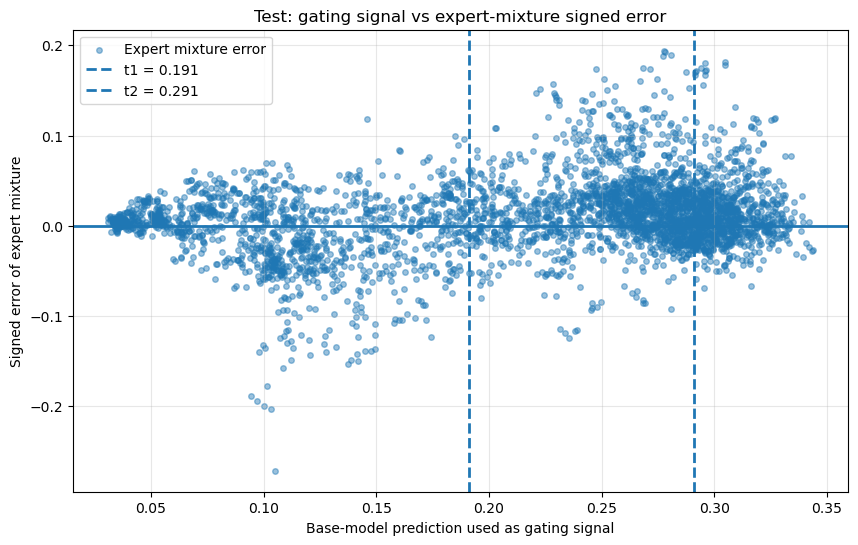

In [67]:
signed_err_soft = soft_plot - y_plot
signed_err_base = base_plot - y_plot

plt.figure(figsize=(10, 6))
plt.scatter(base_plot, signed_err_soft, s=16, alpha=0.45, label="Expert mixture error")
plt.axhline(0.0, linewidth=2)
plt.axvline(t1, linestyle="--", linewidth=2, label=f"t1 = {t1:.3f}")
plt.axvline(t2, linestyle="--", linewidth=2, label=f"t2 = {t2:.3f}")

plt.xlabel("Base-model prediction used as gating signal")
plt.ylabel("Signed error of expert mixture")
plt.title("Test: gating signal vs expert-mixture signed error")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

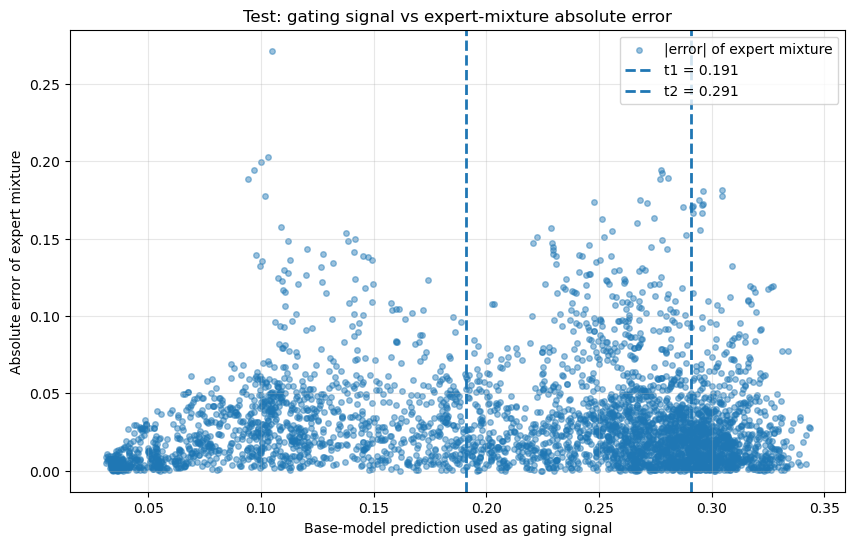

In [68]:
plt.figure(figsize=(10, 6))
plt.scatter(base_plot, abs_err_soft, s=16, alpha=0.45, label="|error| of expert mixture")
plt.axvline(t1, linestyle="--", linewidth=2, label=f"t1 = {t1:.3f}")
plt.axvline(t2, linestyle="--", linewidth=2, label=f"t2 = {t2:.3f}")

plt.xlabel("Base-model prediction used as gating signal")
plt.ylabel("Absolute error of expert mixture")
plt.title("Test: gating signal vs expert-mixture absolute error")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

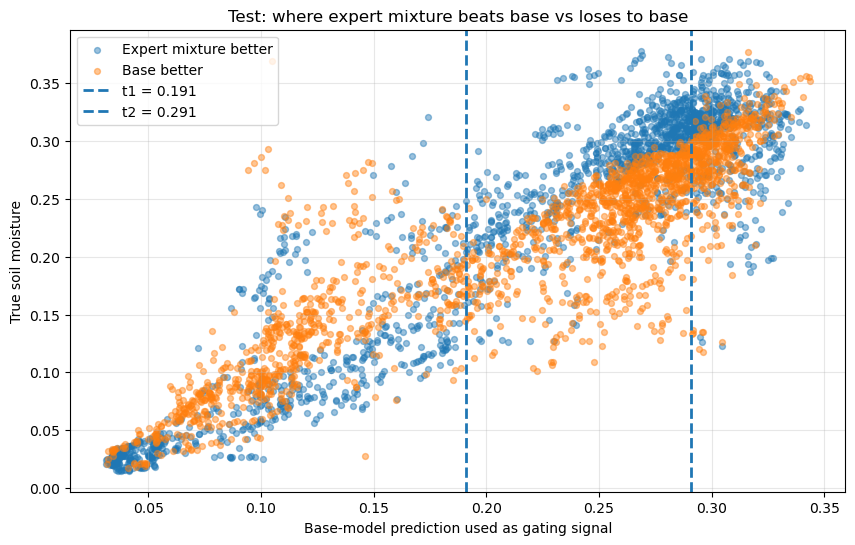

In [69]:
plt.figure(figsize=(10, 6))

plt.scatter(
    base_plot[expert_better],
    y_plot[expert_better],
    s=18,
    alpha=0.45,
    label="Expert mixture better"
)

plt.scatter(
    base_plot[base_better],
    y_plot[base_better],
    s=18,
    alpha=0.45,
    label="Base better"
)

plt.axvline(t1, linestyle="--", linewidth=2, label=f"t1 = {t1:.3f}")
plt.axvline(t2, linestyle="--", linewidth=2, label=f"t2 = {t2:.3f}")

plt.xlabel("Base-model prediction used as gating signal")
plt.ylabel("True soil moisture")
plt.title("Test: where expert mixture beats base vs loses to base")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

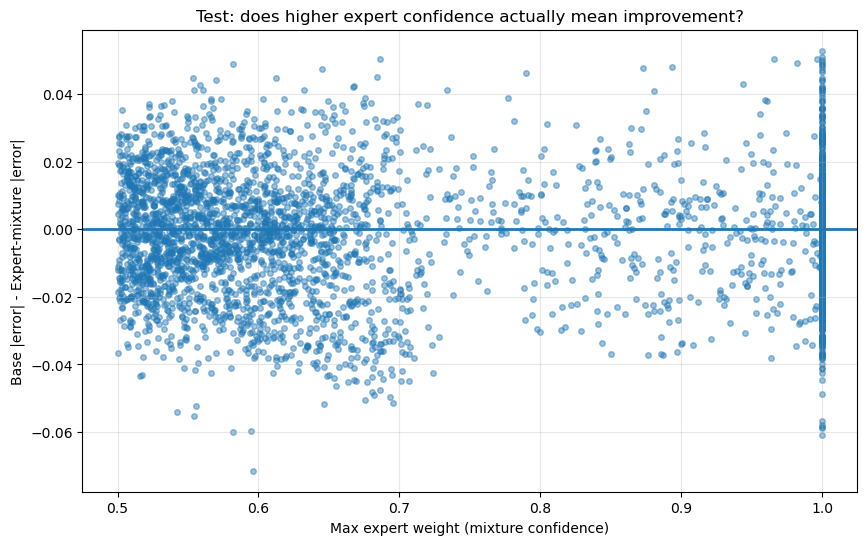

In [70]:
improvement = abs_err_base - abs_err_soft   # positive means experts helped

plt.figure(figsize=(10, 6))
plt.scatter(expert_conf, improvement, s=16, alpha=0.45)
plt.axhline(0.0, linewidth=2)

plt.xlabel("Max expert weight (mixture confidence)")
plt.ylabel("Base |error| - Expert-mixture |error|")
plt.title("Test: does higher expert confidence actually mean improvement?")
plt.grid(alpha=0.3)
plt.show()

In [71]:
df_compare = pd.DataFrame({
    "near_boundary": near_boundary,
    "abs_err_base": abs_err_base,
    "abs_err_soft": abs_err_soft,
    "expert_better": expert_better
})

print(
    df_compare.groupby("near_boundary")[["abs_err_base", "abs_err_soft", "expert_better"]]
    .mean()
)

               abs_err_base  abs_err_soft  expert_better
near_boundary                                           
False              0.029043      0.032121       0.459489
True               0.028485      0.029246       0.485323


---

_Jakob Balkovec_